# Análisis Exploratorio de Datos (EDA): Optimización de Estrategias de Marketing Digital

## Contexto del Proyecto

Este análisis forma parte de una iniciativa estratégica para **InsightReach**, empresa líder en marketing digital especializada en campañas personalizadas para negocios locales. Con el objetivo de optimizar la segmentación de clientes y mejorar la efectividad de las campañas publicitarias, se ha desarrollado este estudio comprehensivo sobre el ecosistema gastronómico estadounidense.

## Objetivo Estratégico

El presente análisis exploratorio busca generar insights accionables que permitan:

- **Optimizar la segmentación de mercado** para campañas más efectivas
- **Identificar oportunidades de negocio** en mercados emergentes
- **Desarrollar perfiles de usuario** basados en patrones de comportamiento
- **Fundamentar decisiones estratégicas** con evidencia empírica sólida

## Metodología

Se aplica un enfoque científico estructurado que incluye exploración de datos, detección de patrones, identificación de problemas de calidad y generación de recomendaciones fundamentadas en hallazgos estadísticamente significativos.

---

## Análisis Exploratorio de Datos: Base de Restaurantes y Usuarios

### Resumen Ejecutivo

Este notebook presenta un análisis exploratorio comprehensivo de datos sobre restaurantes y usuarios en Estados Unidos, diseñado para identificar patrones de comportamiento, preferencias de consumo y oportunidades de mercado que informen estrategias de marketing digital personalizadas.

### Objetivos Específicos

**1. Análisis de Calidad de Datos**
- Evaluación de completitud, consistencia y precisión
- Identificación y documentación de anomalías
- Establecimiento de protocolos de limpieza

**2. Caracterización del Mercado**
- Distribución geográfica y demográfica de usuarios
- Análisis de preferencias alimentarias y patrones de gasto
- Segmentación por comportamiento de consumo

**3. Perfilado de Establecimientos**
- Análisis de oferta gastronómica por ubicación
- Identificación de factores de éxito (ratings, reviews)
- Mapping de precios y categorías

**4. Generación de Insights Estratégicos**
- Identificación de nichos de mercado desatendidos
- Correlaciones entre variables de negocio
- Recomendaciones para optimización de campañas

---

> **Nota Metodológica:** Este análisis sigue estándares industriales de ciencia de datos, garantizando reproducibilidad, trazabilidad y rigor estadístico en todos los procedimientos aplicados.

## Estructura del Análisis

1. **Carga y descripción de los datos**
   - Importación de librerías
   - Carga de datasets
   - Inspección inicial (shape, head, info, describe)
2. **Limpieza y preprocesamiento**
   - Unificación y transformación de columnas
   - Tratamiento de valores nulos y atípicos
   - Conversión de tipos de datos
   - Imputación y eliminación de duplicados

## 1. Configuración del Entorno y Carga de Datos

### Importación de Librerías y Configuración

Esta sección establece el entorno de trabajo necesario para el análisis, incluyendo la importación de librerías especializadas para manipulación de datos, visualización estadística y análisis exploratorio.

### Adquisición y Validación de Datos

El proceso de carga incluye validaciones iniciales de integridad, verificación de esquemas de datos y establecimiento de protocolos de manejo de errores para garantizar la calidad del análisis posterior.

**Fuentes de Datos:**
- Dataset principal de restaurantes con metadatos enriquecidos
- Base de usuarios con información demográfica y preferencias
- Variables de geolocalización y características de negocio

---

In [1]:
# Importación de librerías
import pandas as pd # Manipulación de datos
import numpy as np # Operaciones matemáticas y estadísticas 
from IPython.display import display # Para mostrar DataFrames en Jupyter Notebook, aunque no es estrictamente necesario, es una buena práctica para visualizar los datos de manera más clara sin usar extensiones adicionales
from tools import imputar, plot_custom # Importamos la función imputar y plot_custom desde el archivo tools.py, donde modularizamos ciertas funciones que reutilizaremos a lo largo del proyecto para asi no repetir tanto codigo.
import matplotlib.pyplot as plt # Visualización de datos
import seaborn as sns # Visualización de datos avanzada

### Importación del DataFrame a trabajar

In [2]:
df_restaurante_original = pd.read_csv("base_datos_restaurantes_USA_v2.csv") # Como está alojado en la misma carpeta, no es necesario poner la ruta completa

df_res = df_restaurante_original.copy() # Copia del DataFrame original para evitar modificarlo directamente

### Comenzaremos conociendo la forma de nuestro DataFrame, lo que significa poder dimensionar el tamaño de los datos

In [3]:
print(f"El DataFrame tiene {df_res.shape[0]} filas y {df_res.shape[1]} columnas.") # 0 para filas, 1 para columnas

El DataFrame tiene 30000 filas y 17 columnas.


### Mostraremos las primeras 10 filas del documento para dar un vistazo a los datos que tenemos. Importante para empezar a hacer un análisis exploratorio preeliminar y conocer cómo estos datos están clasificados (principalmente con el nombre de las columnas)

In [4]:
display(df_res.head(10)) # Muestra las primeras 10 filas del DataFrame

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.0,Femenino,San Diego,Bajo,0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350
5,1291749568,Donna,Davis,26.0,Femenino,Dallas,Alto,6,52.47,No,Sí,Carnes,Sí,976.606.6259x578,daniel28@example.com,Efectivo,8545
6,3592027247,Jason,Mcpherson,80.0,Masculino,NYC,Muy Alto,10,56.11,No,No,Vegano,Sí,001-327-542-1940x4789,bcastillo@example.org,Efectivo,10120
7,8373803828,Julie,Russo,66.0,Femenino,Boston,Muy Alto,9,19.94,No,Sí,Vegetariano,Sí,NaN,NaN,Efectivo,13456
8,7395628831,Mark,Hall,31.0,Masculino,NYC,Medio,5,16.17,No,Sí,Vegetariano,No,NaN,kara70@example.com,App,3350
9,5394273061,Sara,Ball,37.0,Femenino,Boston,Bajo,1,11.35,Sí,No,Carnes,No,563-346-4749x6591,smithstacy@example.com,Efectivo,1197


### Hacemos un pequeño ciclo para conocer el nombre y cantidad de columnas totales que hay en nuestro DataFrame. Si bien en el anterior punto pudimos verlas en conjunto con los valores, el observarlas de manera individual y numerizada ayuda a que podamos tener más presentes estas categorias

In [5]:
for i, column in enumerate(df_res.columns, 1):
    print(f"{i} : {column}")

1 : id_persona
2 : nombre
3 : apellido
4 : edad
5 : genero
6 : ciudad_residencia
7 : estrato_socioeconomico
8 : frecuencia_visita
9 : promedio_gasto_comida
10 : ocio
11 : consume_licor
12 : preferencias_alimenticias
13 : membresia_premium
14 : telefono_contacto
15 : correo_electronico
16 : tipo_de_pago_mas_usado
17 : ingresos_mensuales


### Es importante conocer nuestras columnas numéricas y categóricas para poder anticipar el uso de las funciones o herramientas dependiendo qué datos querramos manipular

In [6]:
# Identificar columnas categóricas

columnas_categoricas = df_res.select_dtypes(include='object').columns.tolist() # Clasifica por tipo de dato y devuelve una lista, object para cadenas de texto
print("Columnas categóricas:", columnas_categoricas)
print("Número de columnas categóricas:", len(columnas_categoricas))

# Identificar columnas numéricas

columnas_numericas = df_res.select_dtypes(include='number').columns.tolist() # number para tipos numéricos
print("Columnas numéricas:", columnas_numericas)
print("Número de columnas numéricas:", len(columnas_numericas))

Columnas categóricas: ['nombre', 'apellido', 'genero', 'ciudad_residencia', 'estrato_socioeconomico', 'ocio', 'consume_licor', 'preferencias_alimenticias', 'membresia_premium', 'telefono_contacto', 'correo_electronico', 'tipo_de_pago_mas_usado']
Número de columnas categóricas: 12
Columnas numéricas: ['id_persona', 'edad', 'frecuencia_visita', 'promedio_gasto_comida', 'ingresos_mensuales']
Número de columnas numéricas: 5


### Una vez conociendo los datos generales de los valores y categorias con las que estaremos trabajando, mostramos información más técnica que nos ayudará a determinar qué categorias o valores necesitan ser limpiados y normalizados para futuros análisis

In [7]:
display(df_res.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 30000 non-null  int64  
 1   nombre                     30000 non-null  object 
 2   apellido                   30000 non-null  object 
 3   edad                       29899 non-null  float64
 4   genero                     30000 non-null  object 
 5   ciudad_residencia          30000 non-null  object 
 6   estrato_socioeconomico     30000 non-null  object 
 7   frecuencia_visita          30000 non-null  int64  
 8   promedio_gasto_comida      29855 non-null  float64
 9   ocio                       30000 non-null  object 
 10  consume_licor              30000 non-null  object 
 11  preferencias_alimenticias  28597 non-null  object 
 12  membresia_premium          30000 non-null  object 
 13  telefono_contacto          14834 non-null  obj

None

### Utilizamos una función incluida en la librería Pandas que nos ayuda a conocer mucho más a detalle información técnica y, sobretodo, estadística. Con esto, es mucho más sencillo poder detectar anomalías o problemáticas más concretas por categoría

In [8]:
display(df_res.describe(include='all')) # el all incluye todas las columnas, no solo las numéricas

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
count,3.000000e+04,30000,30000,29899.000000,30000,30000,30000,30000.000000,29855.000000,30000,30000,28597,30000,14834,14928,30000,30000.000000
unique,NaN,690,1000,NaN,2,10,4,NaN,NaN,2,2,6,2,14834,14474,4,NaN
top,NaN,Michael,Smith,NaN,Femenino,Chicago,Medio,NaN,NaN,No,Sí,Carnes,No,(830)220-1926,pjohnson@example.org,Efectivo,NaN
freq,NaN,678,636,NaN,15044,5384,9325,NaN,NaN,15094,18483,7916,17155,1,4,11813,NaN
mean,5.504765e+09,NaN,NaN,49.665006,NaN,NaN,NaN,3.896133,32.603452,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5389.755867
std,2.602799e+09,NaN,NaN,23.839550,NaN,NaN,NaN,2.741532,26.402601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4538.491728
min,1.000153e+09,NaN,NaN,-5.000000,NaN,NaN,NaN,-3.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,800.000000
25%,3.243617e+09,NaN,NaN,33.000000,NaN,NaN,NaN,2.000000,13.290000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1860.000000
50%,5.515865e+09,NaN,NaN,49.000000,NaN,NaN,NaN,4.000000,25.510000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3402.000000
75%,7.754426e+09,NaN,NaN,65.000000,NaN,NaN,NaN,5.000000,44.400000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7761.000000


### Análisis para la selección de ciudad de enfoque
Antes de continuar con el análisis, es fundamental seleccionar una ciudad que sirva como caso de estudio representativo. Para ello, se realiza un análisis comparativo entre las distintas ciudades presentes en el dataset, considerando los siguientes criterios:
- Cantidad de datos disponibles por ciudad.
- Presencia de valores nulos, ceros y negativos en variables clave (edad, frecuencia de visita, promedio de gasto, preferencias alimenticias).
- Identificación de posibles sesgos o anomalías en la distribución de los datos.
El objetivo es elegir la ciudad con mayor calidad y cantidad de información, minimizando la presencia de valores problemáticos y asegurando la robustez de los análisis posteriores.

In [9]:
df2 = df_restaurante_original.copy() # Creamos una copia del DataFrame original para trabajar en ella

df2['edad'] = np.where ( # Usamos np.where para validar los datos en la columna 'edad'
    (df2['edad'] >= 0) & (df2['edad'] <= 120), # Condición: la edad debe estar entre 0 y 120
     df2['edad'],
     np.nan
)

df2['frecuencia_visita'] = np.where ( # Usamos np.where para validar los datos en la columna 'frecuencia_visita'
    df2['frecuencia_visita'] > 0,
     df2['frecuencia_visita'],
     np.nan
)

df2['promedio_gasto_comida'] = np.where ( # Usamos np.where para validar los datos en la columna 'promedio_gasto_comida'
    df2['promedio_gasto_comida'] > 0,
     df2['promedio_gasto_comida'],
     np.nan
)

 # Muestra estadísticas descriptivas de todas las columnas, incluyendo las categóricas

nulos_por_ciudad = (
    df2.groupby('ciudad_residencia')
    .apply(lambda x: x.isna().sum())
)

nulos_por_ciudad['total nulos'] = nulos_por_ciudad[
    ['edad', 'frecuencia_visita', 'promedio_gasto_comida', 'preferencias_alimenticias']
].sum(axis=1)


print(nulos_por_ciudad)
ciudad_min = nulos_por_ciudad['total nulos'].idxmin()

print("La ciudad con menor cantidad de nulos es:", ciudad_min)


                   id_persona  nombre  apellido  edad  genero  \
ciudad_residencia                                               
Boston                      0       0         0    24       0   
Chicago                     0       0         0    52       0   
Dallas                      0       0         0    33       0   
Denver                      0       0         0    28       0   
Houston                     0       0         0    26       0   
Miami                       0       0         0    36       0   
NYC                         0       0         0    52       0   
Phoenix                     0       0         0     8       0   
San Diego                   0       0         0    28       0   
Seattle                     0       0         0    21       0   

                   ciudad_residencia  estrato_socioeconomico  \
ciudad_residencia                                              
Boston                             0                       0   
Chicago                    

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15728\1796342340.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isna().sum())


In [10]:
#Calcular datos por ciudad
tabla_ciudad = df2.groupby('ciudad_residencia')['id_persona'].count() 

sorted_ciudad = tabla_ciudad.sort_values(ascending=False) # Ordenar de mayor a menor

sorted_ciudad 

ciudad_residencia
Chicago      5384
NYC          4769
Miami        3186
San Diego    3075
Dallas       2602
Boston       2547
Denver       2523
Houston      2212
Seattle      2191
Phoenix      1511
Name: id_persona, dtype: int64

In [11]:
df2

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6.0,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2.0,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2.0,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5.0,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.0,Femenino,San Diego,Bajo,NaN,NaN,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4862097674,Robert,Cortez,20.0,Masculino,Houston,Alto,NaN,30.82,Sí,Sí,Vegano,Sí,NaN,garciagregory@example.net,Tarjeta,5781
29996,9458262482,Michael,Holt,78.0,Masculino,Denver,Alto,5.0,45.04,No,No,Mariscos,No,NaN,jimmy77@example.org,Efectivo,7652
29997,3412365931,Rebecca,Henry,77.0,Femenino,San Diego,Muy Alto,7.0,93.55,No,Sí,Mariscos,Sí,NaN,NaN,Efectivo,12639
29998,8853079811,Tamara,Griffin,77.0,Femenino,Chicago,Bajo,1.0,6.18,Sí,No,Otro,No,(243)658-6543x11668,NaN,Tarjeta,1057


c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, data=df, order=order, palette=palette)


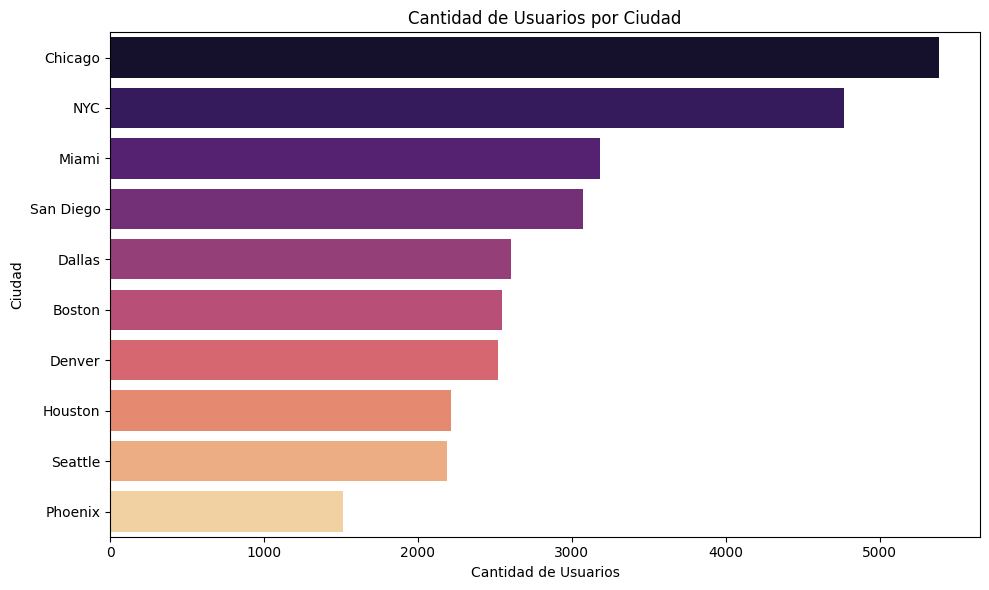

In [12]:
# Calcular la cantidad de personas por ciudad
usuarios_por_ciudad = df_res.groupby('ciudad_residencia')['id_persona'].count().sort_values(ascending=False).reset_index()
# Graficar usando plot_custom
plot_custom(
    usuarios_por_ciudad,
    'bar',
    x='id_persona',
    y='ciudad_residencia',
    palette='magma',
    title='Cantidad de Usuarios por Ciudad',
    xlabel='Cantidad de Usuarios',
    ylabel='Ciudad'
 )

c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, data=df, order=order, palette=palette)


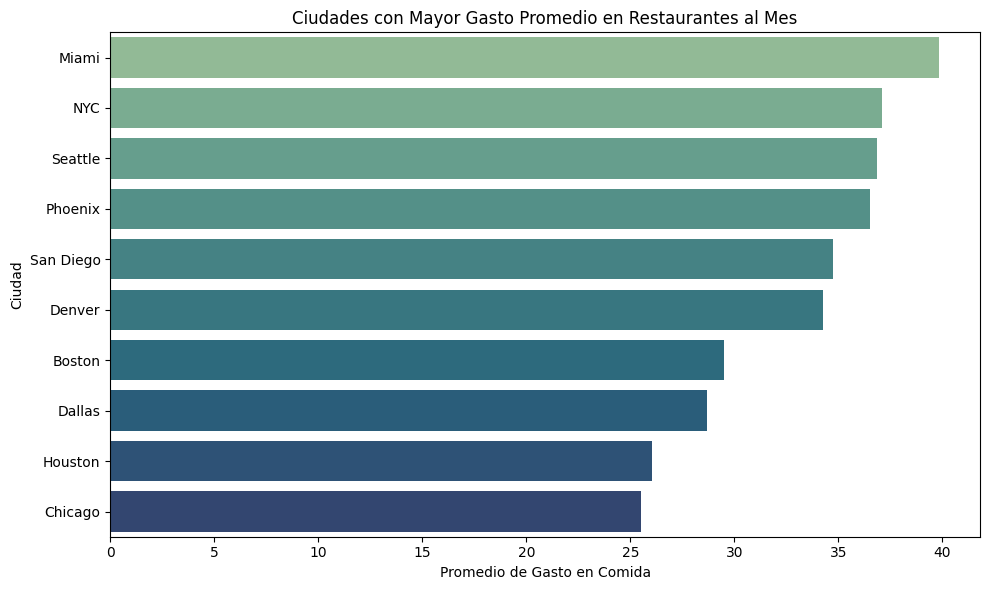

In [13]:
# Gráfico de ciudades con mayor gasto promedio en restaurantes al mes usando plot_custom
gasto_promedio_ciudad = df_res.groupby('ciudad_residencia')['promedio_gasto_comida'].mean().sort_values(ascending=False)
plot_custom(
    gasto_promedio_ciudad.reset_index(),
    'bar',
    x='promedio_gasto_comida',
    y='ciudad_residencia',
    palette='crest',
    title='Ciudades con Mayor Gasto Promedio en Restaurantes al Mes',
    xlabel='Promedio de Gasto en Comida',
    ylabel='Ciudad'
 )

#### Resumen de la exploración inicial y próximos pasos
En esta primera etapa, se realizó una exploración preliminar para comprender la estructura y calidad de los datos. Se identificaron los siguientes puntos clave:
- El DataFrame contiene 30,000 filas y 17 columnas, de las cuales 12 son categóricas y 5 numéricas.
- Se observan posibles correlaciones entre el estrato socioeconómico y la frecuencia de visitas a restaurantes.
- Existen valores faltantes en variables como edad, promedio de gasto en comida y preferencias alimenticias. Las columnas de teléfono y correo electrónico presentan más de la mitad de sus valores nulos.
- Se detectaron valores fuera de rango (por ejemplo, edades y frecuencias negativas).
- Hay correos electrónicos duplicados, lo que podría indicar errores o registros repetidos.
- Algunos tipos de datos no corresponden a su contenido, lo que puede generar inconsistencias.
- Se identificaron columnas susceptibles de ser fusionadas o eliminadas sin afectar el análisis.
- La variable de ingresos mensuales presenta valores extremos que podrían sesgar los resultados.
- Es necesario analizar si los valores cero en frecuencia de visitas representan errores o simplemente ausencia de información, ya que se relacionan con otras variables clave.

**Próximo paso:**
A continuación, se procederá a la limpieza y preprocesamiento de los datos, abordando los problemas detectados: tratamiento de valores nulos, duplicados, outliers y corrección de tipos de datos, para asegurar la calidad y robustez de los análisis posteriores.


## 2. Limpieza de datos 

#### Identificación y tratamiento de valores nulos, duplicados y errores
En esta sección se abordarán los principales problemas de calidad detectados en la exploración inicial. El objetivo es dejar el DataFrame listo para análisis avanzados, asegurando que los datos sean consistentes, completos y adecuados para su uso.

Las tareas principales serán:
- Resolver valores nulos y fuera de rango mediante imputación o eliminación, según corresponda.
- Identificar y tratar valores duplicados.
- Corregir tipos de datos incorrectos.
- Fusionar o eliminar columnas irrelevantes.

------

### Unificación de columnas de nombre y apellido
Para simplificar el DataFrame y facilitar el análisis, se fusionan las columnas de nombre y apellido en una sola columna denominada `nombre_completo`, ubicada en la segunda posición del DataFrame. Si en futuros análisis se requiere separar nuevamente estos datos, el proceso es reversible de forma sencilla.

In [14]:
# Unificar los valores de nombre y apellido en una sola columna

df_res['nombre_completo'] = df_res['nombre'] + ' ' + df_res['apellido'] # concatenar nombre y apellido en una nueva columna
df_res.drop(columns=['nombre', 'apellido'], inplace=True) # eliminar las columnas originales de nombre y apellido

In [15]:
# Mover la columna 'nombre_completo' al principio del DataFrame

columnas = df_res.columns.tolist() # Obtener la lista de columnas
columnas.remove('nombre_completo') # Eliminar 'nombre_completo' de su posición actual
columnas.insert(1, 'nombre_completo')  # Insertar en el segundo lugar (posición 1)
df_res = df_res[columnas] # Reordenar el DataFrame con la nueva lista de columnas

In [16]:
df_res.head() # Muestra las primeras filas del DataFrame actualizado

,id_persona,nombre_completo,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson Gomez,31.0,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan Jones,49.0,Femenino,San Diego,Bajo,0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350


### Tratamiento de valores nulos y fuera de rango en la columna 'edad'
Tras unificar las columnas irrelevantes, abordamos uno de los aspectos más críticos de la limpieza: el tratamiento de valores nulos y atípicos en la columna `edad`. Se identificaron tanto datos faltantes como valores imposibles (fuera de un rango realista).
Para asegurar la calidad de la variable, se establecieron límites razonables entre 18 y 120 años: el mínimo de 18 evita problemas por manipulación de datos sensibles de menores de edad, y el máximo de 120 responde a criterios realistas. Los valores fuera de este rango, así como los nulos, serán imputados utilizando la mediana por estado, ya que esta medida es menos sensible a valores extremos que la media y garantiza mayor coherencia y realismo en los datos. Para todo este proceso, se utiliza la función personalizada `imputar` desarrollada en `tools.py`, lo que permite modularidad y evita la repetición de código en el análisis.

In [17]:
# Definir el rango permitido
min_edad = 18
max_edad = 120

# Filtrar los valores fuera de rango
fuera_rango = df_res[(df_res['edad'] < min_edad) | (df_res['edad'] > max_edad)]

# Mostrar como lista de diccionarios (o puedes usar .to_dict('records') para lista de filas)
fuera_rango_list = fuera_rango[['id_persona', 'edad']].to_dict('records')
len(fuera_rango_list)

207

In [18]:
# Corregir valores fuera de rango en edad

df_res.loc[ # .loc permite seleccionar filas y columnas por etiquetas 
    (df_res['edad'] > 120) | (df_res['edad'] < 18), 'edad'    # corregir valores fuera de rango en edad
    ] = df_res['edad'].median() # reemplazar por la mediana 

df_res.describe() # Verificar si se aplicó el cambio correctamente, revisando minimo, máximo y media de la columna 'edad' 

,id_persona,edad,frecuencia_visita,promedio_gasto_comida,ingresos_mensuales
count,3.000000e+04,29899.000000,30000.000000,29855.000000,30000.000000
mean,5.504765e+09,48.916753,3.896133,32.603452,5389.755867
std,2.602799e+09,18.097158,2.741532,26.402601,4538.491728
min,1.000153e+09,18.000000,-3.000000,0.000000,800.000000
25%,3.243617e+09,33.000000,2.000000,13.290000,1860.000000
50%,5.515865e+09,49.000000,4.000000,25.510000,3402.000000
75%,7.754426e+09,64.000000,5.000000,44.400000,7761.000000
max,9.999627e+09,80.000000,10.000000,149.970000,17999.000000


Una vez corregidos los valores fuera de rango en la columna `edad`, procedemos a imputar los valores nulos restantes. Para lograr una mayor precisión, la imputación se realiza utilizando la mediana calculada por ciudad de residencia y estrato socioeconómico. Para este proceso, utilizamos la función personalizada `imputar` desarrollada en `tools.py`, lo que nos permite evitar la repetición de código y mantener el análisis modular y eficiente. Finalmente, se convierte la columna a tipo entero para asegurar la consistencia de los datos.

In [19]:
edad_nulos = imputar(
    df_res,
    objetivo='edad',
    operacion='nulo', # Que se quiere tratar
    filtro1='ciudad_residencia', # Filtro por ciudad de residencia
    filtro2='estrato_socioeconomico', # Filtro por estrato social
    tc='mediana' # Tipo de cálculo, en este caso la media
)

df_res.info() # Verificar si se aplicó el cambio correctamente, revisando si hay valores nulos en la columna 'edad'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 30000 non-null  int64  
 1   nombre_completo            30000 non-null  object 
 2   edad                       30000 non-null  float64
 3   genero                     30000 non-null  object 
 4   ciudad_residencia          30000 non-null  object 
 5   estrato_socioeconomico     30000 non-null  object 
 6   frecuencia_visita          30000 non-null  int64  
 7   promedio_gasto_comida      29855 non-null  float64
 8   ocio                       30000 non-null  object 
 9   consume_licor              30000 non-null  object 
 10  preferencias_alimenticias  28597 non-null  object 
 11  membresia_premium          30000 non-null  object 
 12  telefono_contacto          14834 non-null  object 
 13  correo_electronico         14928 non-null  obj

In [20]:
# Cambiar tipo de dato de la edad a entero
df_res['edad'] = df_res['edad'].astype(int) # Convertir la columna 'edad' a tipo entero
df_res.info() # Verificar si se aplicó el cambio correctamente, revisando el tipo de dato de la columna 'edad'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 30000 non-null  int64  
 1   nombre_completo            30000 non-null  object 
 2   edad                       30000 non-null  int64  
 3   genero                     30000 non-null  object 
 4   ciudad_residencia          30000 non-null  object 
 5   estrato_socioeconomico     30000 non-null  object 
 6   frecuencia_visita          30000 non-null  int64  
 7   promedio_gasto_comida      29855 non-null  float64
 8   ocio                       30000 non-null  object 
 9   consume_licor              30000 non-null  object 
 10  preferencias_alimenticias  28597 non-null  object 
 11  membresia_premium          30000 non-null  object 
 12  telefono_contacto          14834 non-null  object 
 13  correo_electronico         14928 non-null  obj

### Tratamiento de valores atípicos y nulos en la columna 'frecuencia_visita'
Una vez resueltos los problemas principales de la columna `edad`, abordamos la limpieza de la columna `frecuencia_visita`, que también presenta valores fuera de rango y nulos. Aplicaremos una lógica similar, pero adaptando los filtros y criterios según la naturaleza de esta variable.

Antes de imputar o corregir los valores, realizamos un análisis exploratorio de los valores fuera de rango en `frecuencia_visita`. En la exploración inicial se detectaron valores negativos (por ejemplo, -3), por lo que es fundamental analizar su origen y decidir el mejor criterio de corrección para evitar sesgos en el análisis posterior.

In [21]:
# Tabla de frecuencia para los valores de la columna 'frecuencia_visita'
frecuencia_tabla = df_res['frecuencia_visita'].value_counts().sort_index()
print("Tabla de frecuencia de 'frecuencia_visita':")
print(frecuencia_tabla)

Tabla de frecuencia de 'frecuencia_visita':
frecuencia_visita
-3     1547
 0     1463
 1     1459
 2     3659
 3     3697
 4     5042
 5     5932
 6     3746
 7      878
 8      862
 9      839
 10     876
Name: count, dtype: int64


In [22]:
# Revisamos el número de valores negativos en las columnas 'frecuencia_visita' y 'promedio_gasto_comida' para identificar conexiones con otros datos

print("Valores negativos por columna:")
for col in ['frecuencia_visita', 'promedio_gasto_comida']:
    negativos = df_res[df_res[col] < 0]
    print(f"{col}: {len(negativos)} valores negativos")

Valores negativos por columna:
frecuencia_visita: 1547 valores negativos
promedio_gasto_comida: 0 valores negativos


In [23]:
# Revisamos valores igual a 3 en el campo 'frecuencia_visita' para identificar si, en caso de utilizar el valor absoluto de 3, que tanto afectaría a los datos

print("Valores negativos por columna:")
for col in ['frecuencia_visita', 'promedio_gasto_comida']:
    negativos = df_res[df_res[col] == 3]
    print(f"{col}: {len(negativos)} tres")

Valores negativos por columna:
frecuencia_visita: 3697 tres
promedio_gasto_comida: 0 tres


In [24]:
# Analizamos si los negativos se concentran en ciertas ciudades, estratos o personas 

print("\nDistribución de negativos por ciudad (frecuencia_visita):")
print(df_res[df_res['frecuencia_visita'] < 0]['ciudad_residencia'].value_counts())

print("\nDistribución de negativos por estrato (frecuencia_visita):")
print(df_res[df_res['frecuencia_visita'] < 0]['estrato_socioeconomico'].value_counts())


Distribución de negativos por ciudad (frecuencia_visita):
ciudad_residencia
Chicago      286
NYC          264
Miami        173
San Diego    164
Dallas       128
Boston       123
Denver       115
Seattle      114
Houston      110
Phoenix       70
Name: count, dtype: int64

Distribución de negativos por estrato (frecuencia_visita):
estrato_socioeconomico
Medio       500
Alto        469
Bajo        308
Muy Alto    270
Name: count, dtype: int64


In [25]:
# Ver si hay relación con otras columnas (por ejemplo, edad, ingresos)
print("\nEstadísticas de edad para negativos en frecuencia_visita:")
print(df_res[df_res['frecuencia_visita'] < 0]['edad'].describe())


Estadísticas de edad para negativos en frecuencia_visita:
count    1547.000000
mean       48.142211
std        18.064437
min        18.000000
25%        33.000000
50%        48.000000
75%        64.000000
max        80.000000
Name: edad, dtype: float64


Después del análisis de datos y compararlos con otras columnas con las que podría tener relación, tomamos la decisión de seguir imputando con la media tomada por estrato y ciudad, ya que de solo cambiar por el valor absoluto, todo se inclina a solo un valor por lo que es más sesgado para futuros análisis. Utilizamos nuestra función importada 'imputar'

In [26]:
# Función para imputar los valores negativos en 'frecuencia_visita' utilizando la media por ciudad y estrato socioeconómico

frec_negativos = imputar(
    
    df_res, 
    objetivo='frecuencia_visita', 
    operacion='negativo', 
    filtro1='ciudad_residencia', 
    filtro2='estrato_socioeconomico', 
    tc='media'
)
df_res['frecuencia_visita'] = df_res['frecuencia_visita'].astype(int)  # Asegurarse de que la columna sea de tipo entero

c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:227: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[5.01903367 7.58283133 5.01903367 ... 3.42586207 4.99309392 5.00564972]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[objetivo] < 0, objetivo] = df.loc[df[objetivo] < 0, "media_segmentada"]


Una vez cambiados los valores por debajo de 0, notamos una correlación directa entre esta categoría y el promedio gasto visita, ya que cuando la frecuencia es 0, también lo es en esta otra categoria, y a su vez con su estrato economico, por lo que es importante revisar esto ya que sino, existirian inconsistencias y sesgos a la hora de hacer análisis más profundos, por lo que es importante decidir los próximos pasos

In [27]:
# calcular cuantos 0 hay en la columna promedio_gasto_comida y frecuencia_visita para confirmar que son iguales 

cantidad_0_promedio_gasto = df_res['promedio_gasto_comida'].value_counts().get(0, 0)
print("Cantidad de 0 en la columna promedio_gasto_comida:", cantidad_0_promedio_gasto)

cantidad_0_frecuencia_visita = df_res['frecuencia_visita'].value_counts().get(0, 0)
print("Cantidad de 0 en la columna frecuencia_visita:", cantidad_0_frecuencia_visita)

Cantidad de 0 en la columna promedio_gasto_comida: 1463
Cantidad de 0 en la columna frecuencia_visita: 1463


Debido a que son dos columnas que parecen tener relación directa y es riesgoso imputarlas, se decidió eliminar aquellas filas donde el estrato social sea 'bajo' y la frecuencia en conjunto con el promedio gasto comida sea 0

In [28]:
# Eliminar filas donde 'promedio_gasto_comida' o 'frecuencia_visita' sean 0
df_res = df_res[(df_res['promedio_gasto_comida'] != 0) & (df_res['frecuencia_visita'] != 0)]
print(f"Filas restantes después de eliminar ceros: {df_res.shape[0]}")

Filas restantes después de eliminar ceros: 28537


Es necesario cambiar el tipo de dato de esta columna

In [29]:
# Cambio de tipo de dato en la columna frecuencia_visita a entero
df_res['frecuencia_visita'] = df_res['frecuencia_visita'].astype(int) # convertir frecuencia_visita a entero
df_res.info() # Verificar el cambio de tipo de dato

<class 'pandas.core.frame.DataFrame'>
Index: 28537 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 28537 non-null  int64  
 1   nombre_completo            28537 non-null  object 
 2   edad                       28537 non-null  int64  
 3   genero                     28537 non-null  object 
 4   ciudad_residencia          28537 non-null  object 
 5   estrato_socioeconomico     28537 non-null  object 
 6   frecuencia_visita          28537 non-null  int64  
 7   promedio_gasto_comida      28392 non-null  float64
 8   ocio                       28537 non-null  object 
 9   consume_licor              28537 non-null  object 
 10  preferencias_alimenticias  27191 non-null  object 
 11  membresia_premium          28537 non-null  object 
 12  telefono_contacto          14083 non-null  object 
 13  correo_electronico         14183 non-null  object 


C:\Users\Usuario\AppData\Local\Temp\ipykernel_15728\3717019863.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['frecuencia_visita'] = df_res['frecuencia_visita'].astype(int) # convertir frecuencia_visita a entero


### Tratamiento de valores nulos y atípicos en la columna 'promedio_gasto_comida'
Una vez completada la limpieza de las columnas anteriores, abordamos la columna `promedio_gasto_comida`, que también presenta valores nulos y posibles outliers. Aplicaremos estrategias de imputación y validación para asegurar la calidad y representatividad de esta variable clave para el análisis.

Comenzamos imputando aquellos valores que son nulos, lo haremos con la media pero tomando en cuenta el estrato y la ciudad, ya que así podemos segmentar de mejor manera y así los datos pueden estar más cercanos a la realidad

In [30]:
prom_nulos = imputar(
    df_res,
    objetivo='promedio_gasto_comida',
    operacion='nulo', # Que se quiere tratar
    filtro1='ciudad_residencia', # Filtro por ciudad de residencia
    filtro2='estrato_socioeconomico', # Filtro por estrato social
    tc='media' # Tipo de cálculo, en este caso la media
)

# Redondear la columna a 2 decimales
df_res["promedio_gasto_comida"] = df_res["promedio_gasto_comida"].round(2)

df_res.info() # Verificar si se aplicó el cambio correctamente, revisando si hay valores nulos en la columna 'promedio_gasto_comida'

c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:215: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["media_segmentada"] = (
c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:220: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns="media_segmentada", inplace=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_15728\1135888384.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

<class 'pandas.core.frame.DataFrame'>
Index: 28537 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 28537 non-null  int64  
 1   nombre_completo            28537 non-null  object 
 2   edad                       28537 non-null  int64  
 3   genero                     28537 non-null  object 
 4   ciudad_residencia          28537 non-null  object 
 5   estrato_socioeconomico     28537 non-null  object 
 6   frecuencia_visita          28537 non-null  int64  
 7   promedio_gasto_comida      28537 non-null  float64
 8   ocio                       28537 non-null  object 
 9   consume_licor              28537 non-null  object 
 10  preferencias_alimenticias  27191 non-null  object 
 11  membresia_premium          28537 non-null  object 
 12  telefono_contacto          14083 non-null  object 
 13  correo_electronico         14183 non-null  object 


### Imputación de valores nulos en la columna 'preferencias_alimenticias'
Continuando con el tratamiento de valores nulos, abordamos la columna `preferencias_alimenticias`, que presenta menos problemáticas. Para mantener la coherencia y segmentación, imputamos los valores faltantes utilizando la moda por ciudad y estrato socioeconómico, aplicando la función `imputar` para asegurar un enfoque contextualizado y eficiente.

Para ello, necesitamos recordar los valores únicos de esta columna

In [31]:
conteo_valores = df_res['preferencias_alimenticias'].value_counts() # contar valores únicos en la columna preferencias_alimenticias
print("Conteo de valores únicos en preferencias_alimenticias:")
print(conteo_valores)

Conteo de valores únicos en preferencias_alimenticias:
preferencias_alimenticias
Carnes         7508
Vegetariano    6271
Mariscos       4966
Vegano         3105
Pescado        2831
Otro           2510
Name: count, dtype: int64


Una vez teniendo presente estas sub-categorias, pasamos a realizar la imputación con la moda de la columna pero tomando en cuenta la ciudad y el estrato economico. Usamos nuestra función importada 'imputar'

In [32]:
alimntos_nulos = imputar(
    df_res,
    objetivo='preferencias_alimenticias',
    operacion='nulo', # Que se quiere tratar
    filtro1='ciudad_residencia', # Filtro por ciudad de residencia
    filtro2='estrato_socioeconomico', # Filtro por estrato social
    tc='moda' # Tipo de cálculo, en este caso la moda
)

df_res.info() # Verificar si se aplicó el cambio correctamente, revisando si hay valores nulos en la columna 'preferencias_alimenticias'

<class 'pandas.core.frame.DataFrame'>
Index: 28537 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 28537 non-null  int64  
 1   nombre_completo            28537 non-null  object 
 2   edad                       28537 non-null  int64  
 3   genero                     28537 non-null  object 
 4   ciudad_residencia          28537 non-null  object 
 5   estrato_socioeconomico     28537 non-null  object 
 6   frecuencia_visita          28537 non-null  int64  
 7   promedio_gasto_comida      28537 non-null  float64
 8   ocio                       28537 non-null  object 
 9   consume_licor              28537 non-null  object 
 10  preferencias_alimenticias  28537 non-null  object 
 11  membresia_premium          28537 non-null  object 
 12  telefono_contacto          14083 non-null  object 
 13  correo_electronico         14183 non-null  object 


c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:269: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["moda_segmentada"] = (
c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:274: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns="moda_segmentada", inplace=True)


### Imputación de valores nulos en 'telefono_contacto' y 'correo_electronico'
Para finalizar con la imputación de valores faltantes, abordamos las columnas `telefono_contacto` y `correo_electronico`, que presentan un alto porcentaje de datos nulos. La decisión más adecuada sería dejar estos valores como están, ya que su ausencia no afecta el análisis principal. Sin embargo, por fines educativos y para mostrar el proceso, imputamos los valores nulos con 'No Aplica', dado que el tamaño del DataFrame lo permite sin generar distorsiones significativas.

Imputamos la columna 'telefono_contacto' con 'No_aplica'

In [33]:
# Imputación de valores faltantes en las columnas 'telefono_contacto' con 'No Aplica' 

df_res['telefono_contacto'] = df_res['telefono_contacto'].fillna('No_aplica')
df_res.info()
df_res.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
Index: 28537 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 28537 non-null  int64  
 1   nombre_completo            28537 non-null  object 
 2   edad                       28537 non-null  int64  
 3   genero                     28537 non-null  object 
 4   ciudad_residencia          28537 non-null  object 
 5   estrato_socioeconomico     28537 non-null  object 
 6   frecuencia_visita          28537 non-null  int64  
 7   promedio_gasto_comida      28537 non-null  float64
 8   ocio                       28537 non-null  object 
 9   consume_licor              28537 non-null  object 
 10  preferencias_alimenticias  28537 non-null  object 
 11  membresia_premium          28537 non-null  object 
 12  telefono_contacto          28537 non-null  object 
 13  correo_electronico         14183 non-null  object 


C:\Users\Usuario\AppData\Local\Temp\ipykernel_15728\3178134035.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['telefono_contacto'] = df_res['telefono_contacto'].fillna('No_aplica')


,id_persona,nombre_completo,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
count,2.853700e+04,28537,28537.000000,28537,28537,28537,28537.000000,28537.000000,28537,28537,28537,28537,28537,14183,28537,28537.000000
unique,NaN,24415,NaN,2,10,4,NaN,NaN,2,2,6,2,14084,13769,4,NaN
top,NaN,David Williams,NaN,Femenino,Chicago,Medio,NaN,NaN,No,Sí,Carnes,No,No_aplica,kjones@example.org,Efectivo,NaN
freq,NaN,11,NaN,14283,5123,9325,NaN,NaN,14350,17587,8345,15697,14454,3,11252,NaN
mean,5.508510e+09,NaN,48.855801,NaN,NaN,NaN,4.467674,34.275907,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5604.482917
std,2.603988e+09,NaN,18.080383,NaN,NaN,NaN,2.104973,25.948466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4550.343403
min,1.000153e+09,NaN,18.000000,NaN,NaN,NaN,1.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,800.000000
25%,3.249536e+09,NaN,33.000000,NaN,NaN,NaN,3.000000,14.540000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2099.000000
50%,5.516035e+09,NaN,49.000000,NaN,NaN,NaN,4.000000,27.090000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3659.000000
75%,7.762721e+09,NaN,64.000000,NaN,NaN,NaN,6.000000,45.710000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7967.000000


Al igual que con el número de teléfono, rellenamos los valores nulos con 'No aplica' en 'correo_electrónico'

In [34]:
df_res['correo_electronico'] = df_res['correo_electronico'].fillna('No_aplica')
df_res.info()
df_res.describe(include='all')
df_res 

<class 'pandas.core.frame.DataFrame'>
Index: 28537 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 28537 non-null  int64  
 1   nombre_completo            28537 non-null  object 
 2   edad                       28537 non-null  int64  
 3   genero                     28537 non-null  object 
 4   ciudad_residencia          28537 non-null  object 
 5   estrato_socioeconomico     28537 non-null  object 
 6   frecuencia_visita          28537 non-null  int64  
 7   promedio_gasto_comida      28537 non-null  float64
 8   ocio                       28537 non-null  object 
 9   consume_licor              28537 non-null  object 
 10  preferencias_alimenticias  28537 non-null  object 
 11  membresia_premium          28537 non-null  object 
 12  telefono_contacto          28537 non-null  object 
 13  correo_electronico         28537 non-null  object 


C:\Users\Usuario\AppData\Local\Temp\ipykernel_15728\2521257851.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['correo_electronico'] = df_res['correo_electronico'].fillna('No_aplica')


,id_persona,nombre_completo,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson Gomez,31,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,No_aplica,Efectivo,6425
1,9446112038,Samantha Soto,40,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,No_aplica,Efectivo,2374
2,3098363243,Terry Adams,62,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,No_aplica,diana74@example.net,Efectivo,1110
3,4013002847,James Shannon,41,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,No_aplica,scottfrey@example.com,Tarjeta,6931
5,1291749568,Donna Davis,26,Femenino,Dallas,Alto,6,52.47,No,Sí,Carnes,Sí,976.606.6259x578,daniel28@example.com,Efectivo,8545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4862097674,Robert Cortez,20,Masculino,Houston,Alto,5,30.82,Sí,Sí,Vegano,Sí,No_aplica,garciagregory@example.net,Tarjeta,5781
29996,9458262482,Michael Holt,78,Masculino,Denver,Alto,5,45.04,No,No,Mariscos,No,No_aplica,jimmy77@example.org,Efectivo,7652
29997,3412365931,Rebecca Henry,77,Femenino,San Diego,Muy Alto,7,93.55,No,Sí,Mariscos,Sí,No_aplica,No_aplica,Efectivo,12639
29998,8853079811,Tamara Griffin,77,Femenino,Chicago,Bajo,1,6.18,Sí,No,Otro,No,(243)658-6543x11668,No_aplica,Tarjeta,1057


Después, hacemos una lista donde muestre el correo y la frecuencia de aparición en la columna. Mostramos los primeros 1000 valores

In [35]:
frecuencia_duplicados = df_res['correo_electronico'].value_counts().head(1000)
print("Frecuencia de cada valor en la columna correo_electronico:")
print(frecuencia_duplicados)

Frecuencia de cada valor en la columna correo_electronico:
correo_electronico
No_aplica                    14354
ksmith@example.com               3
rdavis@example.org               3
omorales@example.net             3
christopher19@example.org        3
                             ...  
pkennedy@example.org             1
xsanders@example.org             1
brett19@example.com              1
lauren84@example.com             1
justin81@example.net             1
Name: count, Length: 1000, dtype: int64


In [36]:
# encontrar ids duplicados en la columna id_persona

id_ducplicado = df_res['id_persona'][df_res['id_persona'].duplicated()] # encontrar ids duplicados 
print("IDs duplicados encontrados:", id_ducplicado.tolist()) # imprimir los ids duplicados como lista

IDs duplicados encontrados: []


Se hace un análisis donde revisamos los duplicados. Debido a que dos personas distintas pueden usar el mismo mail, decidimos no realizar ninguna acción ya que es más de la mitad, pero dejamos una pauta para que el equipo de marketing pueda revisar los id's de las personas que tienen el mismo mail

In [37]:
# Filtrar los correos electrónicos que aparecen más de una vez
duplicados = df_res[(df_res.duplicated(subset='correo_electronico', keep=False)) & (df_res['correo_electronico'] != 'No_aplica')] # Filtrar los correos electrónicos duplicados, excluyendo 'No_aplica'

# Ordenar para facilitar la revisión visual
duplicados = duplicados.sort_values('correo_electronico')

# Mostrar solo las columnas relevantes
display(duplicados[['correo_electronico', 'nombre_completo', 'id_persona']])

,correo_electronico,nombre_completo,id_persona
25630,alicia33@example.net,John Conley,4584144878
7330,alicia33@example.net,Katherine Berry,4642197907
22212,alopez@example.com,Cameron Orr,5738967614
12254,alopez@example.com,Mason Miller,7137748626
7114,amanda50@example.com,Tasha Taylor,5455242170
...,...,...,...
6180,zthompson@example.org,Michael Davenport,1987243526
12232,zvasquez@example.org,Kathryn Ortiz,2036388089
5161,zvasquez@example.org,Nicole Thompson,6884723824
11594,zwilliams@example.org,Patricia Calhoun,8117478955


### Conversión de tipo de dato en la columna 'ingresos_mensuales'
Para finalizar el proceso de limpieza, convertimos la columna `ingresos_mensuales` de tipo entero a flotante. Esta conversión permite una mayor precisión en los análisis posteriores y asegura la correcta interpretación de los valores monetarios. Se verifica el cambio al final del proceso.

In [38]:
df_res["ingresos_mensuales"] = df_res["ingresos_mensuales"].astype(float) 

df_res.info()
df_res.describe(include='all')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15728\2882340861.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res["ingresos_mensuales"] = df_res["ingresos_mensuales"].astype(float)


<class 'pandas.core.frame.DataFrame'>
Index: 28537 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 28537 non-null  int64  
 1   nombre_completo            28537 non-null  object 
 2   edad                       28537 non-null  int64  
 3   genero                     28537 non-null  object 
 4   ciudad_residencia          28537 non-null  object 
 5   estrato_socioeconomico     28537 non-null  object 
 6   frecuencia_visita          28537 non-null  int64  
 7   promedio_gasto_comida      28537 non-null  float64
 8   ocio                       28537 non-null  object 
 9   consume_licor              28537 non-null  object 
 10  preferencias_alimenticias  28537 non-null  object 
 11  membresia_premium          28537 non-null  object 
 12  telefono_contacto          28537 non-null  object 
 13  correo_electronico         28537 non-null  object 


,id_persona,nombre_completo,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
count,2.853700e+04,28537,28537.000000,28537,28537,28537,28537.000000,28537.000000,28537,28537,28537,28537,28537,28537,28537,28537.000000
unique,NaN,24415,NaN,2,10,4,NaN,NaN,2,2,6,2,14084,13770,4,NaN
top,NaN,David Williams,NaN,Femenino,Chicago,Medio,NaN,NaN,No,Sí,Carnes,No,No_aplica,No_aplica,Efectivo,NaN
freq,NaN,11,NaN,14283,5123,9325,NaN,NaN,14350,17587,8345,15697,14454,14354,11252,NaN
mean,5.508510e+09,NaN,48.855801,NaN,NaN,NaN,4.467674,34.275907,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5604.482917
std,2.603988e+09,NaN,18.080383,NaN,NaN,NaN,2.104973,25.948466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4550.343403
min,1.000153e+09,NaN,18.000000,NaN,NaN,NaN,1.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,800.000000
25%,3.249536e+09,NaN,33.000000,NaN,NaN,NaN,3.000000,14.540000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2099.000000
50%,5.516035e+09,NaN,49.000000,NaN,NaN,NaN,4.000000,27.090000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3659.000000
75%,7.762721e+09,NaN,64.000000,NaN,NaN,NaN,6.000000,45.710000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7967.000000


### Visualización de la distribución de preferencias alimenticias por ciudad
A continuación, se presenta un gráfico que muestra cómo se distribuyen las preferencias alimenticias entre las distintas ciudades del dataset. Esta visualización permite identificar patrones de consumo y posibles diferencias culturales o demográficas relevantes para el análisis.

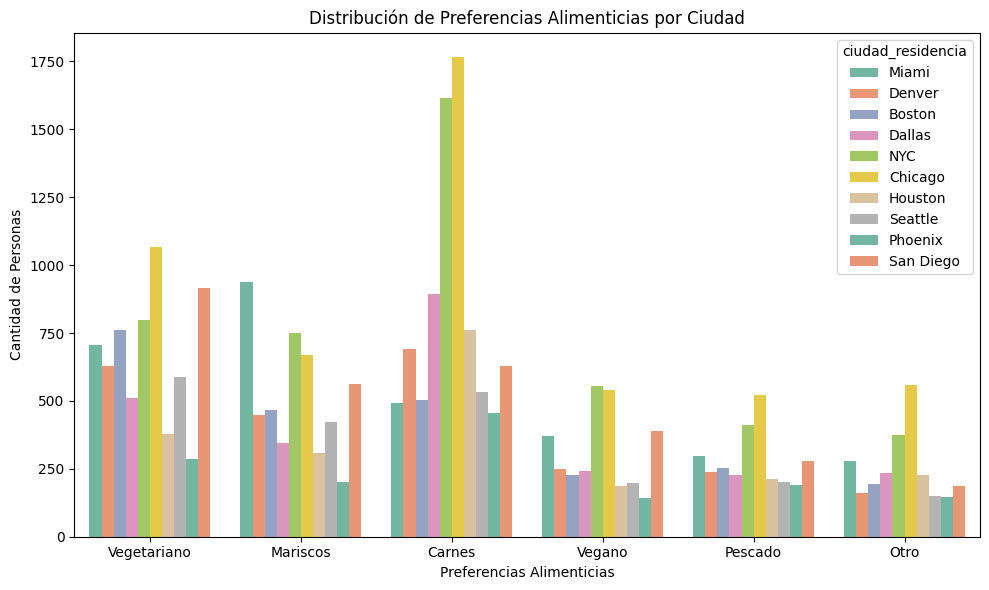

In [39]:
# Mostrar cómo se distribuyen las preferencias alimenticias en todas las ciudades usando plot_custom
plot_custom(
    df_res,
    'count',
    x='preferencias_alimenticias',
    hue='ciudad_residencia',
    palette='Set2',
    title='Distribución de Preferencias Alimenticias por Ciudad',
    xlabel='Preferencias Alimenticias',
    ylabel='Cantidad de Personas'
)

### Preferencias alimenticias y gasto promedio del top 10 de clientes
El siguiente gráfico analiza el perfil de los clientes con mayor gasto promedio en restaurantes, mostrando la relación entre sus preferencias alimenticias y el monto gastado. Esto permite identificar segmentos de alto valor y tendencias de consumo relevantes para estrategias de marketing.

c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, data=df, order=order, palette=palette)


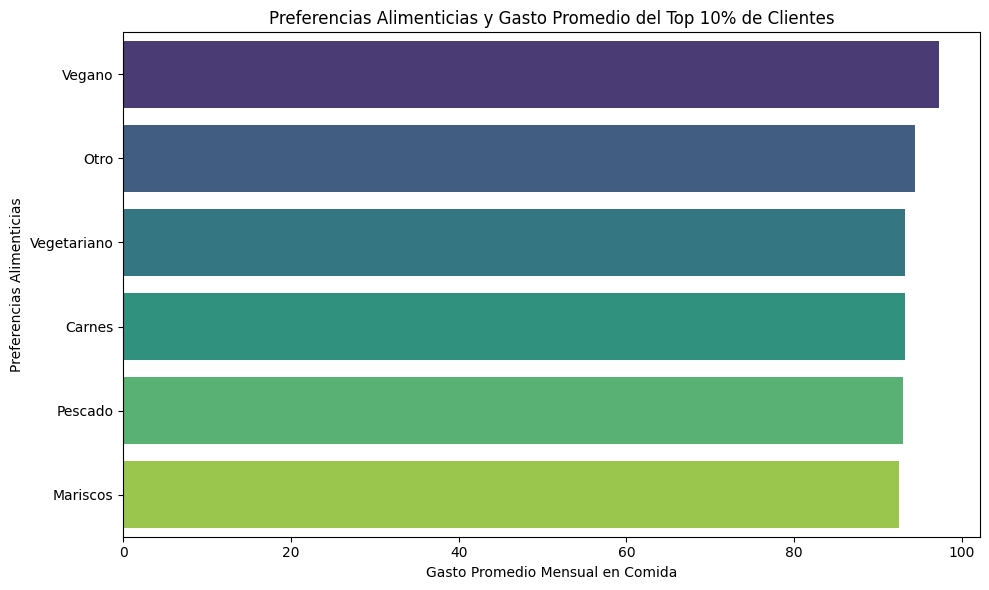

In [40]:
# Perfilar los clientes de mayor gasto: Qué comidas les gustan, cuánto suelen gastar al mes. Usando plot_custom
top_gasto = df_res[df_res['promedio_gasto_comida'] >= df_res['promedio_gasto_comida'].quantile(0.9)]
perfil = top_gasto.groupby('preferencias_alimenticias')['promedio_gasto_comida'].mean().sort_values(ascending=False)
plot_custom(
    perfil.reset_index(),
    'bar',
    x='promedio_gasto_comida',
    y='preferencias_alimenticias',
    palette='viridis',
    title='Preferencias Alimenticias y Gasto Promedio del Top 10% de Clientes',
    xlabel='Gasto Promedio Mensual en Comida',
    ylabel='Preferencias Alimenticias'
 )

### Membresías pagadas por ciudad
Este gráfico muestra la cantidad de membresías premium adquiridas en cada ciudad, permitiendo identificar regiones con mayor adopción de servicios exclusivos y potenciales focos de fidelización de clientes.

In [41]:
# Mapeo robusto para la columna membresia_premium
df_res['membresia_premium'] = df_res['membresia_premium'].map(lambda x: 1 if str(x).strip().lower() in ['sí', 'si'] else 0).astype(int)

# Ahora sí, agrupa y grafica usando plot_custom
membresias_por_ciudad = df_res.groupby('ciudad_residencia')['membresia_premium'].sum().sort_values(ascending=False)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15728\3807053117.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['membresia_premium'] = df_res['membresia_premium'].map(lambda x: 1 if str(x).strip().lower() in ['sí', 'si'] else 0).astype(int)


c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, data=df, order=order, palette=palette)


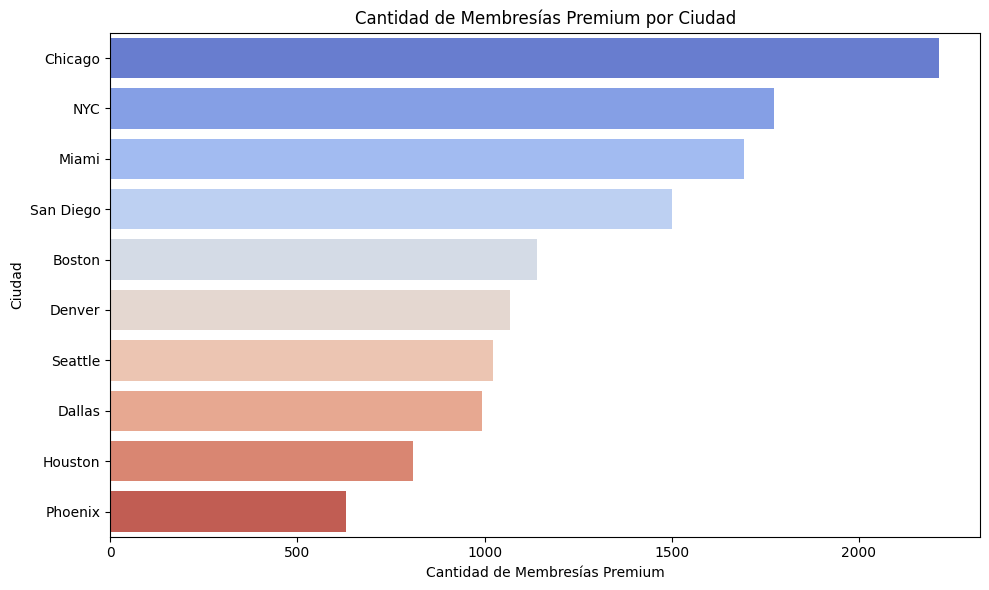

In [42]:
# Visualización profesional: Membresías premium pagadas por ciudad
# Este gráfico de barras muestra la cantidad de usuarios con membresía premium en cada ciudad, permitiendo identificar regiones con mayor adopción de servicios exclusivos y potenciales focos de fidelización. Es útil para orientar estrategias de marketing y expansión comercial hacia los mercados más receptivos a servicios premium.
plot_custom(
    membresias_por_ciudad.reset_index(),
    'bar',
    x='membresia_premium',
    y='ciudad_residencia',
    palette='coolwarm',
    title='Cantidad de Membresías Premium por Ciudad',
    xlabel='Cantidad de Membresías Premium',
    ylabel='Ciudad'
)

### Relación entre consumo de alcohol y edad de los clientes
El siguiente gráfico de caja permite analizar cómo varía la edad de los clientes según su consumo de alcohol en restaurantes, identificando posibles diferencias de comportamiento entre los distintos grupos.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15728\1896400098.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['consume_licor'] = df_res['consume_licor'].map({'Sí': 1, 'No': 0})
c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=x, y=y, palette=palette, hue=hue)


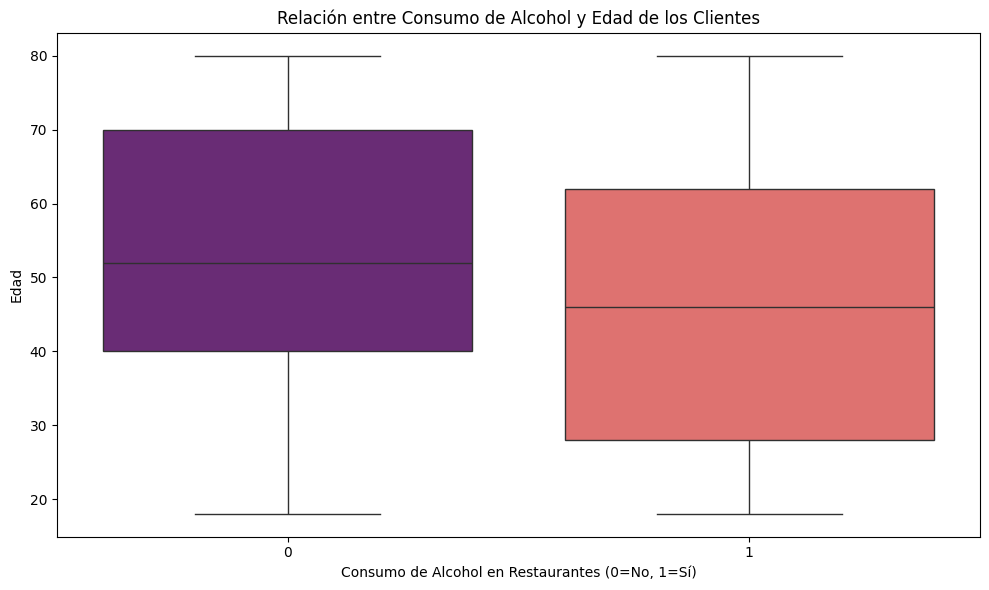

In [43]:
# Gráfico de caja para mostrar la relación entre consumo de alcohol y edad usando plot_custom
# Nota: En el eje X, 0 = 'No consume alcohol', 1 = 'Sí consume alcohol'. Este gráfico permite comparar la distribución de edades según el consumo de alcohol en restaurantes, identificando posibles diferencias de comportamiento entre ambos grupos.
df_res['consume_licor'] = df_res['consume_licor'].map({'Sí': 1, 'No': 0})
plot_custom(
    df_res,
    'box',
    x='consume_licor',
    y='edad',
    title='Relación entre Consumo de Alcohol y Edad de los Clientes',
    xlabel='Consumo de Alcohol en Restaurantes (0=No, 1=Sí)',
    ylabel='Edad',
)

### Distribución de edad según consumo de alcohol
Este gráfico de violín muestra la distribución de edades de los clientes segmentada por su consumo de alcohol en restaurantes, facilitando la comparación de tendencias y dispersiones entre ambos grupos.

c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=x, y=y, palette=palette, hue=hue)


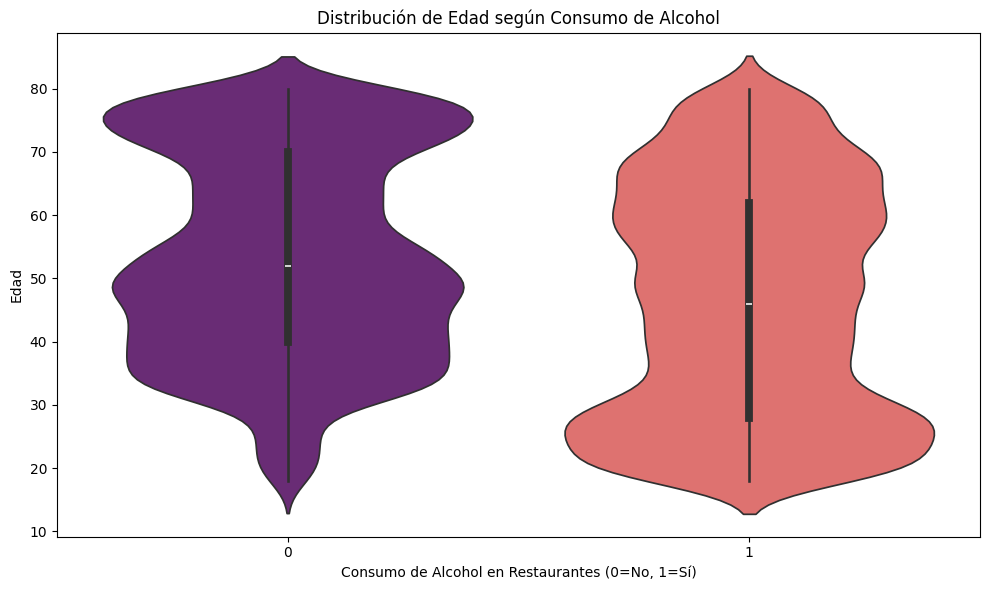

In [44]:
# Gráfico de violín para mostrar la distribución de edad según consumo de alcohol usando plot_custom
plot_custom(
    df_res,
    'violin',
    x='consume_licor',
    y='edad',
    title='Distribución de Edad según Consumo de Alcohol',
    xlabel='Consumo de Alcohol en Restaurantes (0=No, 1=Sí)',
    ylabel='Edad'
)

### Histograma de edad por consumo de alcohol
El siguiente histograma permite visualizar la distribución de edades de los clientes diferenciando entre quienes consumen y no consumen alcohol en restaurantes, facilitando la identificación de patrones y diferencias entre ambos grupos.

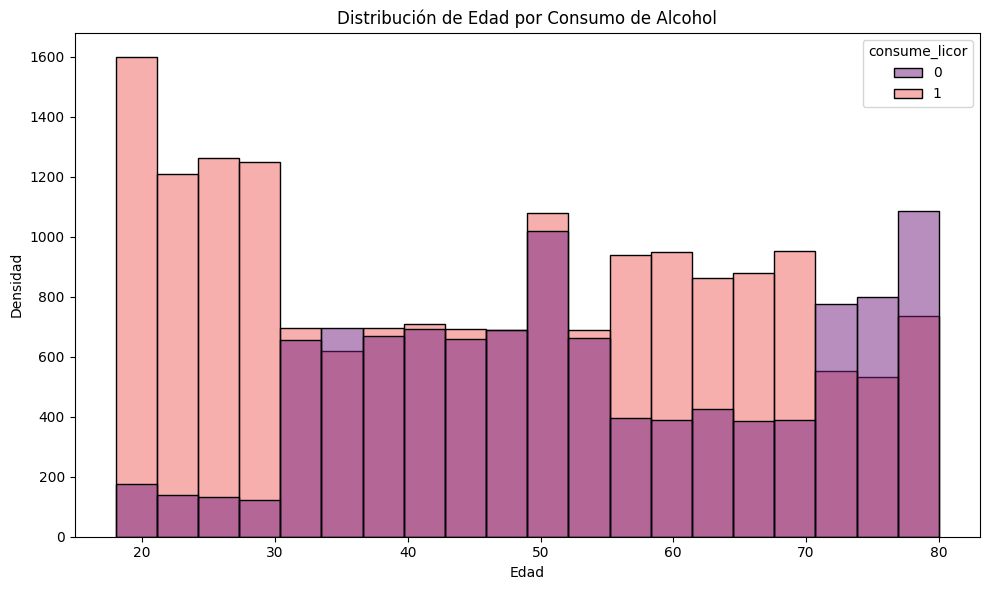

In [45]:
# Histograma de edad por consumo de alcohol usando plot_custom
plot_custom(
    df_res,
    'hist',
    x='edad',
    hue='consume_licor',
    bins=20,
    palette='magma',
    title='Distribución de Edad por Consumo de Alcohol',
    xlabel='Edad',
    ylabel='Densidad'
 )

### Filtrado final por ciudad de interés
Como paso final previo a la exportación, se filtran los datos para conservar únicamente los usuarios residentes en la ciudad de Chicago. Esto permite centrar el análisis y las recomendaciones en un mercado objetivo específico, facilitando la toma de decisiones focalizadas.

In [46]:
# Filtrar solo usuarios de la ciudad de Chicago antes de exportar
df_res = df_res[df_res['ciudad_residencia'] == 'Chicago']

### Eliminación de la columna 'ciudad_residencia' tras el filtrado
Luego de filtrar el DataFrame para conservar únicamente los usuarios residentes en Chicago, la columna `ciudad_residencia` deja de aportar valor analítico, ya que todos los registros pertenecen a la misma ciudad. Por lo tanto, se elimina esta variable para optimizar la estructura del DataFrame y evitar redundancias en los análisis posteriores.

In [47]:
# Eliminamos la variable Ciudad, ya que no es relevante luego del filtrado.
df_res = df_res.drop(columns=['ciudad_residencia'])

### Exportación del DataFrame final limpio
Como paso final del proceso de limpieza y preprocesamiento, se exporta el DataFrame resultante a un archivo CSV. Este archivo contiene únicamente los datos de usuarios residentes en Chicago, ya depurados y normalizados, lo que facilita su uso en análisis posteriores, visualizaciones o desarrollo de modelos predictivos. La exportación sin el índice asegura una estructura limpia y lista para ser utilizada por otros equipos o herramientas de análisis.

In [48]:
# Exportar el DataFrame limpio a un archivo CSV sin incluir el índice

df_res.to_csv('users_chicago.csv', index=False) # Exportar el DataFrame limpio a un archivo CSV sin incluir el índice